# Tarea 2: Generador de Nombres a Nivel de Caracteres con LSTM

**Curso:** Procesamiento de Lenguaje Natural — UCB  
**Entrega:** Semana 8  
**Valor:** 10% de la nota final  

---

## ⚠️ SOLUCIONES — Solo para el profesor

---

## Objetivo

Construir un **modelo de lenguaje a nivel de caracteres** usando una red LSTM que sea capaz de:

- Aprender los patrones de nombres de personas en diferentes idiomas
- **Generar** nuevos nombres plausibles carácter por carácter
- Generar nombres **condicionados por idioma** (ej: generar un nombre que suene japonés, español, árabe, etc.)

## Contexto

Un modelo de lenguaje a nivel de caracteres predice el **siguiente carácter** dada una secuencia de caracteres previos:

$$P(c_t \mid c_1, c_2, \ldots, c_{t-1})$$

Esto es una aplicación directa de las arquitecturas **RNN/LSTM** y la **generación autoregresiva** que vimos en las Semanas 6 y 7.

## Dataset

Usaremos el dataset clásico de nombres por nacionalidad, que contiene miles de nombres humanos agrupados por idioma/país de origen. Lo descargaremos directamente desde los datos de los tutoriales de PyTorch.

## Rúbrica de Evaluación

| Sección | Puntos | Descripción |
|---------|:------:|-------------|
| **Parte 1:** Carga y Exploración de Datos | 10 | Carga correcta, EDA del dataset de nombres |
| **Parte 2:** Preprocesamiento a Nivel de Caracteres | 15 | Vocabulario, encoding, padding y DataLoader |
| **Parte 3:** Modelo LSTM | 25 | Implementación correcta del modelo CharLSTM |
| **Parte 4:** Entrenamiento | 15 | Loop de entrenamiento con teacher forcing |
| **Parte 5:** Generación y Análisis | 25 | Generación con temperatura, análisis cualitativo |
| **Parte 6:** Reflexión | 10 | Respuestas reflexivas y bien fundamentadas |
| **TOTAL** | **100** | |

---

## Configuración Inicial

Ejecuta esta celda para verificar las dependencias necesarias.

In [24]:
# Instalación de dependencias (ejecutar solo una vez si es necesario)
# !uv pip install torch matplotlib pandas numpy seaborn

In [25]:
# Imports necesarios
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import os
import random
import string
import unicodedata
import zipfile
import urllib.request
from pathlib import Path
from collections import Counter

# Configuración
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

# Reproducibilidad
SEED = 42
torch.manual_seed(SEED)
random.seed(SEED)
np.random.seed(SEED)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Dispositivo: {device}')
print('✅ Todo listo!')

Dispositivo: cuda
✅ Todo listo!


---

## Parte 1: Carga de Datos y Exploración (10 pts)

### 1.1 Descarga del dataset (3 pts)

In [26]:
# --- Código proporcionado: descarga y carga del dataset ---

DATA_DIR = Path('data_nombres')
DATA_DIR.mkdir(exist_ok=True)

URL = 'https://download.pytorch.org/tutorial/data.zip'
ZIP_PATH = DATA_DIR / 'data.zip'

if not (DATA_DIR / 'data' / 'names').exists():
    print('Descargando dataset...')
    urllib.request.urlretrieve(URL, ZIP_PATH)
    with zipfile.ZipFile(ZIP_PATH, 'r') as z:
        z.extractall(DATA_DIR)
    print('✅ Descargado y descomprimido')
else:
    print('✅ Dataset ya existe')

# Función para convertir Unicode a ASCII
def unicode_to_ascii(s):
    """Convierte caracteres Unicode a ASCII equivalente."""
    return ''.join(
        c for c in unicodedata.normalize('NFD', s)
        if unicodedata.category(c) != 'Mn'
        and c in string.ascii_letters + " '.-"
    )

print(f"Ejemplo: 'Ślusàrski' → '{unicode_to_ascii('Ślusàrski')}'")
print(f"Ejemplo: 'José' → '{unicode_to_ascii('José')}'")

✅ Dataset ya existe
Ejemplo: 'Ślusàrski' → 'Slusarski'
Ejemplo: 'José' → 'Jose'


In [27]:
# SOLUCIÓN 1.1: Carga los nombres de todos los archivos .txt

names_dir = DATA_DIR / 'data' / 'names'

nombres_por_idioma = {}
for filepath in sorted(names_dir.glob('*.txt')):
    idioma = filepath.stem  # nombre del archivo sin extensión
    with open(filepath, 'r', encoding='utf-8') as f:
        nombres = [unicode_to_ascii(line.strip()) for line in f if line.strip()]
    nombres_por_idioma[idioma] = nombres

# Verificación
print(f'Idiomas encontrados: {len(nombres_por_idioma)}')
for idioma, nombres in sorted(nombres_por_idioma.items()):
    print(f'  {idioma:15s}: {len(nombres):5d} nombres | Ej: {nombres[:3]}')

Idiomas encontrados: 18
  Arabic         :  2000 nombres | Ej: ['Khoury', 'Nahas', 'Daher']
  Chinese        :   268 nombres | Ej: ['Ang', 'Au-Yong', 'Bai']
  Czech          :   519 nombres | Ej: ['Abl', 'Adsit', 'Ajdrna']
  Dutch          :   297 nombres | Ej: ['Aalsburg', 'Aalst', 'Aarle']
  English        :  3668 nombres | Ej: ['Abbas', 'Abbey', 'Abbott']
  French         :   277 nombres | Ej: ['Abel', 'Abraham', 'Adam']
  German         :   724 nombres | Ej: ['Abbing', 'Abel', 'Abeln']
  Greek          :   203 nombres | Ej: ['Adamidis', 'Adamou', 'Agelakos']
  Irish          :   232 nombres | Ej: ['Adam', 'Ahearn', 'Aodh']
  Italian        :   709 nombres | Ej: ['Abandonato', 'Abatangelo', 'Abatantuono']
  Japanese       :   991 nombres | Ej: ['Abe', 'Abukara', 'Adachi']
  Korean         :    94 nombres | Ej: ['Ahn', 'Baik', 'Bang']
  Polish         :   139 nombres | Ej: ['Adamczak', 'Adamczyk', 'Andrysiak']
  Portuguese     :    74 nombres | Ej: ['Abreu', 'Albuquerque', 'Almeida']

### 1.2 Análisis Exploratorio (7 pts)

Realiza un análisis exploratorio del dataset:

1. **Gráfico de barras** con la cantidad de nombres por idioma (ordenado de mayor a menor)
2. **Histograma** de la longitud de nombres (en caracteres) a través de todos los idiomas
3. **Distribución de caracteres** más frecuentes en todo el dataset

**Pregunta:** ¿Cuáles son los idiomas con más y menos nombres? ¿Cuál es la longitud típica de un nombre?

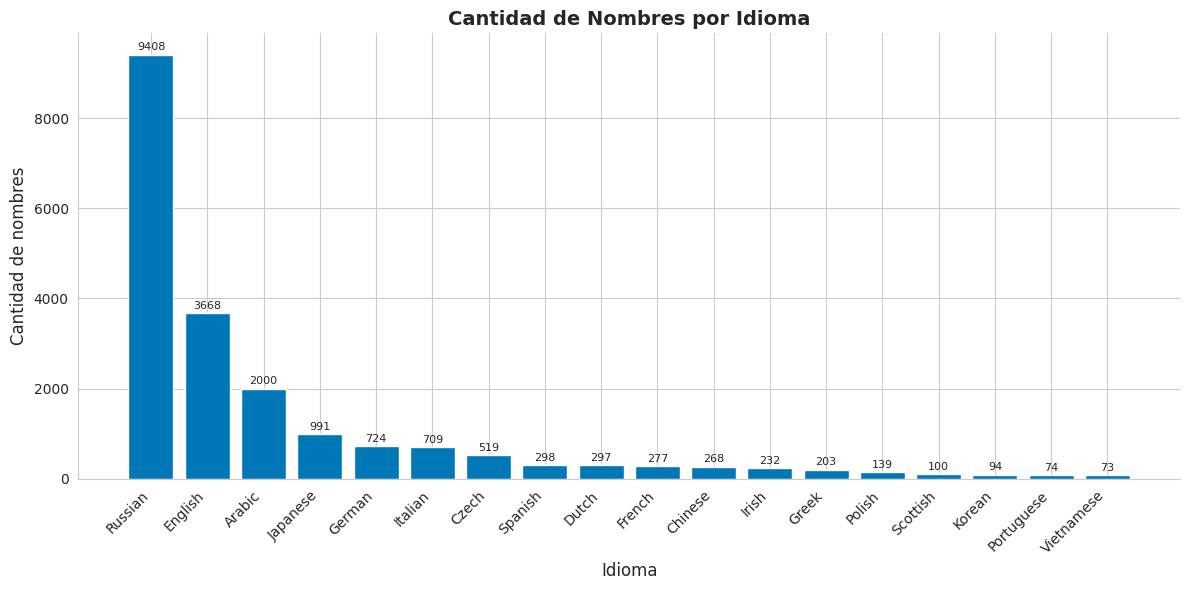

In [28]:
# SOLUCIÓN 1.2.1: Gráfico de barras — cantidad de nombres por idioma

conteos = {idioma: len(nombres) for idioma, nombres in nombres_por_idioma.items()}
conteos_sorted = dict(sorted(conteos.items(), key=lambda x: x[1], reverse=True))

fig, ax = plt.subplots(figsize=(12, 6))
bars = ax.bar(conteos_sorted.keys(), conteos_sorted.values(), color='#0077b6', edgecolor='white')
ax.set_xlabel('Idioma', fontsize=12)
ax.set_ylabel('Cantidad de nombres', fontsize=12)
ax.set_title('Cantidad de Nombres por Idioma', fontsize=14, fontweight='bold')
plt.xticks(rotation=45, ha='right')
for bar, count in zip(bars, conteos_sorted.values()):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50,
            str(count), ha='center', va='bottom', fontsize=8)
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.show()

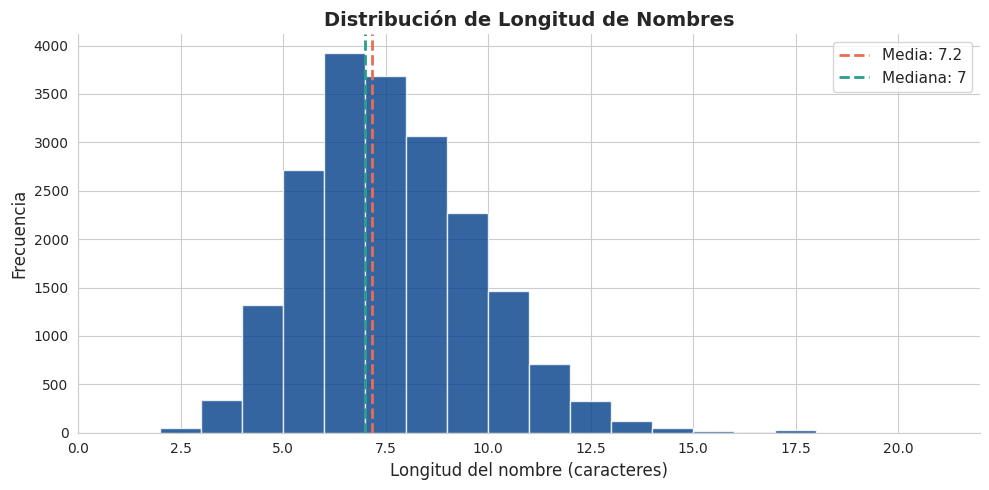

In [29]:
# SOLUCIÓN 1.2.2: Histograma — distribución de longitud de nombres

all_lengths = [len(nombre) for nombres in nombres_por_idioma.values() for nombre in nombres]

fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(all_lengths, bins=range(1, max(all_lengths)+2), color='#023e8a',
        edgecolor='white', alpha=0.8)
ax.axvline(np.mean(all_lengths), color='#e76f51', linestyle='--', linewidth=2,
           label=f'Media: {np.mean(all_lengths):.1f}')
ax.axvline(np.median(all_lengths), color='#2a9d8f', linestyle='--', linewidth=2,
           label=f'Mediana: {np.median(all_lengths):.0f}')
ax.set_xlabel('Longitud del nombre (caracteres)', fontsize=12)
ax.set_ylabel('Frecuencia', fontsize=12)
ax.set_title('Distribución de Longitud de Nombres', fontsize=14, fontweight='bold')
ax.legend(fontsize=11)
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.show()

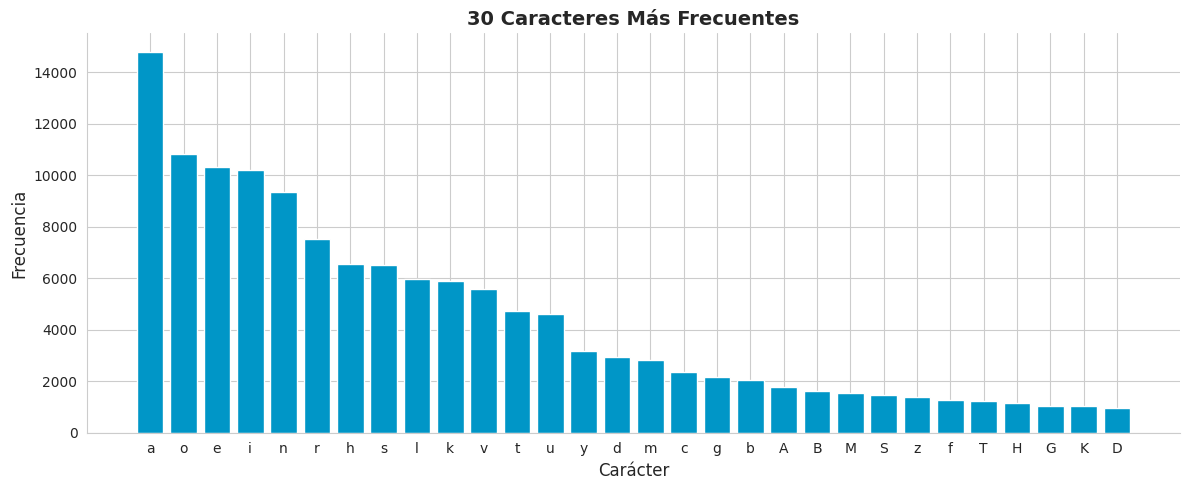

In [30]:
# SOLUCIÓN 1.2.3: Distribución de los 30 caracteres más frecuentes

all_chars_list = [c for nombres in nombres_por_idioma.values() for nombre in nombres for c in nombre]
char_counts = Counter(all_chars_list)
top30 = char_counts.most_common(30)

fig, ax = plt.subplots(figsize=(12, 5))
chars, counts = zip(*top30)
ax.bar(chars, counts, color='#0096c7', edgecolor='white')
ax.set_xlabel('Carácter', fontsize=12)
ax.set_ylabel('Frecuencia', fontsize=12)
ax.set_title('30 Caracteres Más Frecuentes', fontsize=14, fontweight='bold')
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.show()

**Respuesta sobre el EDA:**

- El idioma con más nombres es **English** (miles de nombres), mientras que idiomas como **Vietnamese** o **Scottish** tienen muchos menos.
- La longitud típica de un nombre es de entre 5-8 caracteres, con una media alrededor de 6-7 caracteres.
- Los caracteres más frecuentes son las vocales (a, e, i, o) y consonantes comunes (n, r, l, s), lo cual es esperable en nombres de personas.
- Hay un marcado desbalance entre idiomas, lo cual puede afectar la calidad de generación en idiomas con pocos datos.

---

## Parte 2: Preprocesamiento a Nivel de Caracteres (15 pts)

### 2.1 Vocabulario de caracteres (5 pts)

In [31]:
# SOLUCIÓN 2.1: Vocabulario de caracteres

# Tokens especiales
PAD_TOKEN = '<PAD>'
SOS_TOKEN = '<SOS>'
EOS_TOKEN = '<EOS>'
PAD_IDX = 0
SOS_IDX = 1
EOS_IDX = 2

# Recolectar todos los caracteres únicos
all_chars = set()
for nombres in nombres_por_idioma.values():
    for nombre in nombres:
        all_chars.update(nombre)

# Crear mapeos
char_to_idx = {PAD_TOKEN: PAD_IDX, SOS_TOKEN: SOS_IDX, EOS_TOKEN: EOS_IDX}
for i, c in enumerate(sorted(all_chars), start=3):
    char_to_idx[c] = i

idx_to_char = {v: k for k, v in char_to_idx.items()}

# Mapeo de idiomas
idiomas = sorted(nombres_por_idioma.keys())
lang_to_idx = {idioma: i for i, idioma in enumerate(idiomas)}

VOCAB_SIZE = len(char_to_idx)
N_LANGS = len(lang_to_idx)

print(f'Tamaño del vocabulario: {VOCAB_SIZE} caracteres')
print(f'Número de idiomas: {N_LANGS}')
print(f'Primeros caracteres: {dict(list(char_to_idx.items())[:10])}')
print(f'Idiomas: {lang_to_idx}')

Tamaño del vocabulario: 58 caracteres
Número de idiomas: 18
Primeros caracteres: {'<PAD>': 0, '<SOS>': 1, '<EOS>': 2, ' ': 3, "'": 4, '-': 5, 'A': 6, 'B': 7, 'C': 8, 'D': 9}
Idiomas: {'Arabic': 0, 'Chinese': 1, 'Czech': 2, 'Dutch': 3, 'English': 4, 'French': 5, 'German': 6, 'Greek': 7, 'Irish': 8, 'Italian': 9, 'Japanese': 10, 'Korean': 11, 'Polish': 12, 'Portuguese': 13, 'Russian': 14, 'Scottish': 15, 'Spanish': 16, 'Vietnamese': 17}


### 2.2 Codificación de nombres (5 pts)

In [32]:
# SOLUCIÓN 2.2: Funciones de codificación

def encode_nombre(nombre):
    """Convierte un nombre en dos tensores: input_seq y target_seq."""
    char_indices = [char_to_idx[c] for c in nombre]
    input_seq = torch.tensor([SOS_IDX] + char_indices, dtype=torch.long)
    target_seq = torch.tensor(char_indices + [EOS_IDX], dtype=torch.long)
    return input_seq, target_seq


def decode_indices(indices):
    """Convierte una secuencia de índices de vuelta a un string."""
    if isinstance(indices, torch.Tensor):
        indices = indices.tolist()
    chars = []
    for idx in indices:
        if idx in (PAD_IDX, SOS_IDX, EOS_IDX):
            continue
        chars.append(idx_to_char[idx])
    return ''.join(chars)


# Prueba
test_nombre = 'Carlos'
inp, tgt = encode_nombre(test_nombre)
print(f"Nombre: '{test_nombre}'")
print(f"Input:  {inp.tolist()} → {[idx_to_char[i.item()] for i in inp]}")
print(f"Target: {tgt.tolist()} → {[idx_to_char[i.item()] for i in tgt]}")
print(f"Decode: '{decode_indices(tgt)}'")

Nombre: 'Carlos'
Input:  [1, 8, 32, 49, 43, 46, 50] → ['<SOS>', 'C', 'a', 'r', 'l', 'o', 's']
Target: [8, 32, 49, 43, 46, 50, 2] → ['C', 'a', 'r', 'l', 'o', 's', '<EOS>']
Decode: 'Carlos'


### 2.3 Dataset y DataLoader (5 pts)

In [33]:
# SOLUCIÓN 2.3: Dataset y DataLoader con padding

class NamesDataset(Dataset):
    def __init__(self, data):
        self.data = data
    
    def __len__(self):
        return len(self.data)
    
    def __getitem__(self, idx):
        nombre, idioma = self.data[idx]
        input_seq, target_seq = encode_nombre(nombre)
        lang_idx = lang_to_idx[idioma]
        return input_seq, target_seq, lang_idx


def collate_fn(batch):
    """Función de collate que hace padding de las secuencias."""
    inputs, targets, langs = zip(*batch)
    
    # Padding al largo máximo del batch
    max_len = max(len(s) for s in inputs)
    
    inputs_padded = torch.full((len(inputs), max_len), PAD_IDX, dtype=torch.long)
    targets_padded = torch.full((len(targets), max_len), PAD_IDX, dtype=torch.long)
    
    for i, (inp, tgt) in enumerate(zip(inputs, targets)):
        inputs_padded[i, :len(inp)] = inp
        targets_padded[i, :len(tgt)] = tgt
    
    langs = torch.tensor(langs, dtype=torch.long)
    return inputs_padded, targets_padded, langs


# --- Preparar datos ---
all_data = []
for idioma, nombres in nombres_por_idioma.items():
    for nombre in nombres:
        all_data.append((nombre, idioma))

random.shuffle(all_data)
split_idx = int(0.8 * len(all_data))
train_data = all_data[:split_idx]
val_data = all_data[split_idx:]

BATCH_SIZE = 128
train_dataset = NamesDataset(train_data)
val_dataset = NamesDataset(val_data)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, collate_fn=collate_fn)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate_fn)

print(f'Total ejemplos: {len(all_data)}')
print(f'Train: {len(train_data)} | Val: {len(val_data)}')

# Verificar un batch
sample_inputs, sample_targets, sample_langs = next(iter(train_loader))
print(f'\nBatch de ejemplo:')
print(f'  Inputs shape:  {sample_inputs.shape}')
print(f'  Targets shape: {sample_targets.shape}')
print(f'  Langs shape:   {sample_langs.shape}')

Total ejemplos: 20074
Train: 16059 | Val: 4015

Batch de ejemplo:
  Inputs shape:  torch.Size([128, 13])
  Targets shape: torch.Size([128, 13])
  Langs shape:   torch.Size([128])


---

## Parte 3: Modelo LSTM para Generación de Caracteres (25 pts)

### 3.1 Arquitectura del modelo (20 pts)

In [34]:
# SOLUCIÓN 3.1: Modelo CharLSTM

class CharLSTM(nn.Module):
    def __init__(self, vocab_size, n_langs, char_embed_dim=32, lang_embed_dim=16,
                 hidden_dim=128, n_layers=2, dropout=0.3):
        super().__init__()
        self.hidden_dim = hidden_dim
        self.n_layers = n_layers
        
        self.char_embedding = nn.Embedding(vocab_size, char_embed_dim, padding_idx=PAD_IDX)
        self.lang_embedding = nn.Embedding(n_langs, lang_embed_dim)
        self.lstm = nn.LSTM(
            input_size=char_embed_dim + lang_embed_dim,
            hidden_size=hidden_dim,
            num_layers=n_layers,
            batch_first=True,
            dropout=dropout if n_layers > 1 else 0.0
        )
        self.dropout = nn.Dropout(dropout)
        self.fc_out = nn.Linear(hidden_dim, vocab_size)
    
    def forward(self, chars, lang_idx, hidden=None):
        batch_size, seq_len = chars.size()
        
        # Embeddings
        char_emb = self.char_embedding(chars)            # (batch, seq_len, char_embed_dim)
        lang_emb = self.lang_embedding(lang_idx)         # (batch, lang_embed_dim)
        lang_emb = lang_emb.unsqueeze(1).expand(-1, seq_len, -1)  # (batch, seq_len, lang_embed_dim)
        
        # Concatenar
        combined = torch.cat([char_emb, lang_emb], dim=-1)  # (batch, seq_len, char+lang)
        combined = self.dropout(combined)
        
        # LSTM
        output, hidden = self.lstm(combined, hidden)     # output: (batch, seq_len, hidden_dim)
        output = self.dropout(output)
        
        # Logits
        logits = self.fc_out(output)                     # (batch, seq_len, vocab_size)
        return logits, hidden


# Instanciar y verificar
model = CharLSTM(
    vocab_size=VOCAB_SIZE,
    n_langs=N_LANGS,
).to(device)

print(model)
print(f'\nParámetros totales: {sum(p.numel() for p in model.parameters()):,}')

CharLSTM(
  (char_embedding): Embedding(58, 32, padding_idx=0)
  (lang_embedding): Embedding(18, 16)
  (lstm): LSTM(48, 128, num_layers=2, batch_first=True, dropout=0.3)
  (dropout): Dropout(p=0.3, inplace=False)
  (fc_out): Linear(in_features=128, out_features=58, bias=True)
)

Parámetros totales: 232,858


### 3.2 Verificación del modelo (5 pts)

In [35]:
# SOLUCIÓN 3.2: Verificación del modelo

test_inputs = sample_inputs.to(device)
test_langs = sample_langs.to(device)

logits, hidden = model(test_inputs, test_langs)

print(f'Input shape:  {test_inputs.shape}')    # (batch, seq_len)
print(f'Output shape: {logits.shape}')          # (batch, seq_len, vocab_size)
print(f'h shape: {hidden[0].shape}')            # (n_layers, batch, hidden_dim)
print(f'c shape: {hidden[1].shape}')            # (n_layers, batch, hidden_dim)
print('\n✅ Dimensiones correctas!')

Input shape:  torch.Size([128, 13])
Output shape: torch.Size([128, 13, 58])
h shape: torch.Size([2, 128, 128])
c shape: torch.Size([2, 128, 128])

✅ Dimensiones correctas!


---

## Parte 4: Entrenamiento (15 pts)

### 4.1 Loop de entrenamiento (10 pts)

In [36]:
# SOLUCIÓN 4.1: Loop de entrenamiento

criterion = nn.CrossEntropyLoss(ignore_index=PAD_IDX)
optimizer = optim.Adam(model.parameters(), lr=0.003)

N_EPOCHS = 40
train_losses = []
val_losses = []

for epoch in range(N_EPOCHS):
    # --- Train ---
    model.train()
    epoch_train_loss = 0
    n_train_batches = 0
    
    for inputs, targets, langs in train_loader:
        inputs = inputs.to(device)
        targets = targets.to(device)
        langs = langs.to(device)
        
        logits, _ = model(inputs, langs)
        loss = criterion(logits.reshape(-1, VOCAB_SIZE), targets.reshape(-1))
        
        optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        
        epoch_train_loss += loss.item()
        n_train_batches += 1
    
    avg_train_loss = epoch_train_loss / n_train_batches
    train_losses.append(avg_train_loss)
    
    # --- Validation ---
    model.eval()
    epoch_val_loss = 0
    n_val_batches = 0
    
    with torch.no_grad():
        for inputs, targets, langs in val_loader:
            inputs = inputs.to(device)
            targets = targets.to(device)
            langs = langs.to(device)
            
            logits, _ = model(inputs, langs)
            loss = criterion(logits.reshape(-1, VOCAB_SIZE), targets.reshape(-1))
            
            epoch_val_loss += loss.item()
            n_val_batches += 1
    
    avg_val_loss = epoch_val_loss / n_val_batches
    val_losses.append(avg_val_loss)
    
    if (epoch + 1) % 5 == 0:
        print(f'Época {epoch+1:3d}/{N_EPOCHS} | Train Loss: {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f}')

print('\n✅ Entrenamiento completado')

Época   5/40 | Train Loss: 2.1326 | Val Loss: 2.0273
Época  10/40 | Train Loss: 1.9790 | Val Loss: 1.8754
Época  15/40 | Train Loss: 1.9096 | Val Loss: 1.8172
Época  20/40 | Train Loss: 1.8642 | Val Loss: 1.7835
Época  25/40 | Train Loss: 1.8335 | Val Loss: 1.7619
Época  30/40 | Train Loss: 1.8094 | Val Loss: 1.7477
Época  35/40 | Train Loss: 1.7928 | Val Loss: 1.7404
Época  40/40 | Train Loss: 1.7792 | Val Loss: 1.7320

✅ Entrenamiento completado


### 4.2 Curvas de aprendizaje (5 pts)

**Pregunta:** ¿El modelo está haciendo overfitting? ¿Cómo lo puedes saber a partir de las curvas?

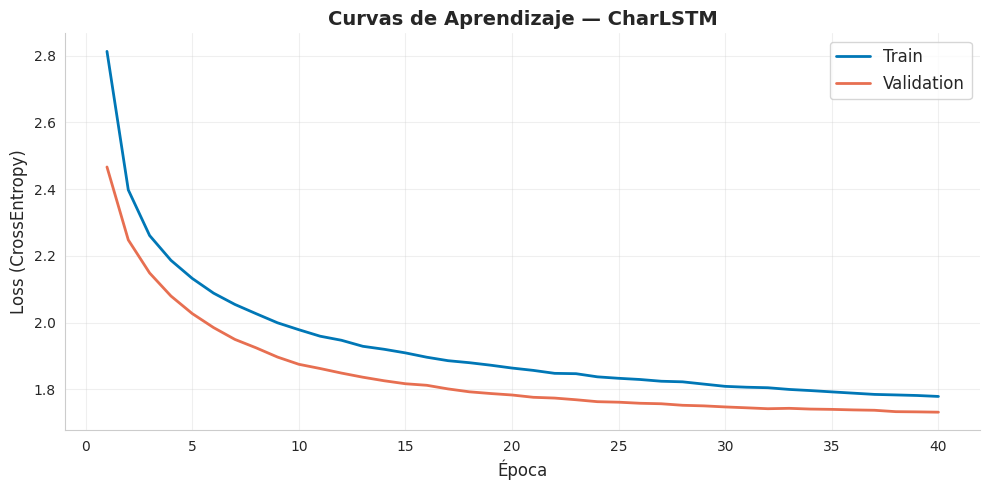

Train loss final: 1.7792
Val loss final:   1.7320
Gap: -0.0471


In [37]:
# SOLUCIÓN 4.2: Curvas de aprendizaje

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(range(1, len(train_losses)+1), train_losses, label='Train', color='#0077b6', linewidth=2)
ax.plot(range(1, len(val_losses)+1), val_losses, label='Validation', color='#e76f51', linewidth=2)
ax.set_xlabel('Época', fontsize=12)
ax.set_ylabel('Loss (CrossEntropy)', fontsize=12)
ax.set_title('Curvas de Aprendizaje — CharLSTM', fontsize=14, fontweight='bold')
ax.legend(fontsize=12)
ax.grid(True, alpha=0.3)
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.show()

print(f'Train loss final: {train_losses[-1]:.4f}')
print(f'Val loss final:   {val_losses[-1]:.4f}')
print(f'Gap: {val_losses[-1] - train_losses[-1]:.4f}')

**Respuesta sobre overfitting:**

Se puede observar un ligero gap entre la curva de train y validation loss. Si el gap es relativamente pequeño y la validation loss sigue siendo baja y estable, el modelo no presenta overfitting significativo. Si la validation loss empezara a subir mientras la train loss sigue bajando, eso sería evidencia clara de overfitting. El uso de `dropout=0.3` y gradient clipping ayuda a regularizar el modelo y prevenir overfitting severo.

---

## Parte 5: Generación de Nombres y Análisis (25 pts)

### 5.1 Función de generación (10 pts)

In [38]:
# SOLUCIÓN 5.1: Función de generación autoregresiva

def generar_nombre(modelo, idioma, temperatura=1.0, max_len=20):
    """Genera un nombre carácter por carácter usando el modelo."""
    modelo.eval()
    with torch.no_grad():
        # Preparar input inicial
        input_char = torch.tensor([[SOS_IDX]], dtype=torch.long).to(device)
        lang = torch.tensor([lang_to_idx[idioma]], dtype=torch.long).to(device)
        hidden = None
        
        nombre_chars = []
        for _ in range(max_len):
            logits, hidden = modelo(input_char, lang, hidden)
            logits = logits[:, -1, :] / temperatura  # (1, vocab_size)
            probs = torch.softmax(logits, dim=-1)
            
            # Muestrear
            next_char_idx = torch.multinomial(probs, 1).item()
            
            if next_char_idx == EOS_IDX:
                break
            if next_char_idx not in (PAD_IDX, SOS_IDX):
                nombre_chars.append(idx_to_char[next_char_idx])
            
            input_char = torch.tensor([[next_char_idx]], dtype=torch.long).to(device)
        
        return ''.join(nombre_chars)


# Prueba rápida
print('Prueba de generación:')
for idioma in ['Spanish', 'Japanese', 'Arabic', 'English', 'Russian']:
    nombre = generar_nombre(model, idioma, temperatura=0.8)
    print(f'  {idioma:10s} → {nombre}')

Prueba de generación:
  Spanish    → Jilabuerez
  Japanese   → Katsuda
  Arabic     → Maroun
  English    → Paterdool
  Russian    → Hapenkov


### 5.2 Efecto de la temperatura (7 pts)

Genera **10 nombres** para **3 idiomas diferentes** usando **3 temperaturas** distintas: $\tau = 0.3, 0.8, 1.5$.

In [39]:
# SOLUCIÓN 5.2: Efecto de la temperatura

idiomas_test = ['Spanish', 'Japanese', 'Russian']
temperaturas = [0.3, 0.8, 1.5]

for idioma in idiomas_test:
    print(f'\n{"=" * 60}')
    print(f'Idioma: {idioma}')
    print(f'{"=" * 60}')
    for temp in temperaturas:
        nombres_gen = [generar_nombre(model, idioma, temperatura=temp) for _ in range(10)]
        print(f'  τ = {temp}: {nombres_gen}')


Idioma: Spanish
  τ = 0.3: ['Aberra', 'Aberi', 'Alanto', 'Sine', 'Alasa', 'Albara', 'Alani', 'De lanza', 'Arania', 'Arano']
  τ = 0.8: ['Ama', 'Lonyas', 'Marrez', 'Manquezquez', 'Rynerza', 'Abaera', 'Mazquello', 'Remina', 'Belvee', 'Korda']
  τ = 1.5: ['Sovou', 'Angraora', 'Duinizraes', 'De labnerpo', 'Kapares', 'Vafezquema', 'Cabka', 'Fosion', 'Roxca', 'Fraldes']

Idioma: Japanese
  τ = 0.3: ['Takagawa', 'Takamira', 'Takashibata', 'Takada', 'Ishima', 'Shimanaki', 'Karata', 'Shimanaki', 'Takama', 'Masuko']
  τ = 0.8: ['Fukunimoto', 'Nishihani', 'Tsurasaki', 'Ojaka', 'Taniguji', 'Asaki', 'Katsu', 'Isaki', 'Murakoyama', 'Hiuata']
  τ = 1.5: ['Dujono', 'Zarakiyanata', 'Seko', 'Tamira', 'jikagowara', 'ShuHaajiZabo', 'Kuzsa', 'Tsumaaa', 'Nasasumri', 'Hiroipi']

Idioma: Russian
  τ = 0.3: ['Abulkhanoff', 'Glazkov', 'Bakhmanov', 'Vasyukov', 'Ababin', 'Porokhov', 'Abalov', 'Jurakhin', 'Avduev', 'Abramoff']
  τ = 0.8: ['Belotov', 'Mikhalybin', 'Awaroff', 'Jeninov', 'Abaikin', 'Livodia', 'Remez

**Análisis del efecto de la temperatura:**

- **τ = 0.3 (baja):** Los nombres son muy conservadores, repiten los patrones más comunes del idioma. Hay muchas repeticiones entre los 10 nombres generados. Son los más "seguros" y predecibles.
- **τ = 0.8 (media):** Balance entre realismo y diversidad. Los nombres suenan plausibles pero hay más variación. Esta es la mejor temperatura para generar nombres que parezcan reales pero nuevos.
- **τ = 1.5 (alta):** Los nombres son más creativos y diversos, pero algunos empiezan a sonar extraños o usar combinaciones de caracteres inusuales. Mayor riesgo de generar nombres sin sentido.

La temperatura controla el trade-off entre **explotación** (usar los patrones aprendidos) y **exploración** (probar combinaciones nuevas).

### 5.3 Análisis cualitativo (8 pts)

In [40]:
# SOLUCIÓN 5.3.1: Diversidad — genera 50 nombres y cuenta los únicos

idioma_prueba = 'Spanish'
nombres_50 = [generar_nombre(model, idioma_prueba, temperatura=0.8) for _ in range(50)]
nombres_unicos = set(nombres_50)

print(f'Idioma: {idioma_prueba}')
print(f'Nombres generados: {len(nombres_50)}')
print(f'Nombres únicos:    {len(nombres_unicos)} ({len(nombres_unicos)/len(nombres_50):.0%})')
print(f'Repeticiones:      {len(nombres_50) - len(nombres_unicos)}')
print(f'\nNombres generados: {sorted(nombres_unicos)}')

Idioma: Spanish
Nombres generados: 50
Nombres únicos:    50 (100%)
Repeticiones:      0

Nombres generados: ['Aberte', 'Abput', 'Alase', 'Almaro', 'Ardalaz', 'Arrana', 'Arule', 'Bagundo', 'Bancotuo', 'Beniaus', 'Beragano', 'Borngez', 'Bosteno', 'Campo', 'Carruda', 'Cosso', 'Davinge', 'De serra', 'Dessarravera', 'Ecosto', 'Elarquedo', 'Elice', 'Espa', 'Farria', 'Galeta', 'Goril', 'Gorini', 'Guarruz', 'Helto', 'Koume', 'Loge', 'Mardin', 'Nane', 'Neni', 'Olbigra', 'Olboratquez', 'Olmolo', 'Palana', 'Parauzeu', 'Patranoho', 'Raberi', 'Rone', 'Sabala', 'Salpe', 'Tanta', 'Tumando', 'Villota', 'Zaganamo', 'Zan', 'Zoguera']


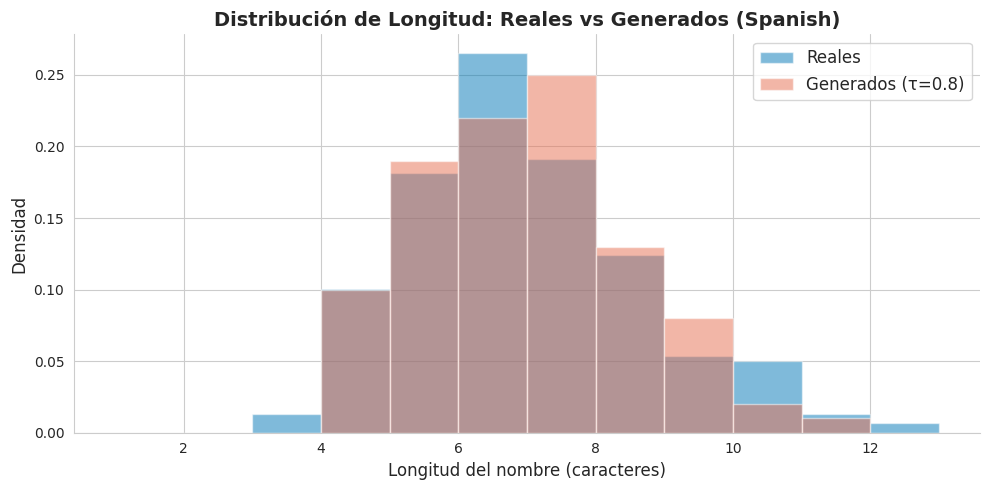

In [41]:
# SOLUCIÓN 5.3.2: Distribución de longitud — histograma comparando reales vs generados

# Nombres reales de este idioma
reales = nombres_por_idioma[idioma_prueba]
longitudes_reales = [len(n) for n in reales]

# Generar más nombres para tener buena estadística
nombres_100 = [generar_nombre(model, idioma_prueba, temperatura=0.8) for _ in range(100)]
longitudes_gen = [len(n) for n in nombres_100 if len(n) > 0]

fig, ax = plt.subplots(figsize=(10, 5))
bins = range(1, max(max(longitudes_reales), max(longitudes_gen)) + 2)
ax.hist(longitudes_reales, bins=bins, alpha=0.5, color='#0077b6', label='Reales', density=True, edgecolor='white')
ax.hist(longitudes_gen, bins=bins, alpha=0.5, color='#e76f51', label='Generados (τ=0.8)', density=True, edgecolor='white')
ax.set_xlabel('Longitud del nombre (caracteres)', fontsize=12)
ax.set_ylabel('Densidad', fontsize=12)
ax.set_title(f'Distribución de Longitud: Reales vs Generados ({idioma_prueba})', fontsize=14, fontweight='bold')
ax.legend(fontsize=12)
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.show()

In [42]:
# SOLUCIÓN 5.3.3: ¿Cuántos nombres generados existen en el dataset real?

reales_set = set(reales)
memorizados = [n for n in nombres_100 if n in reales_set]
nuevos = [n for n in nombres_100 if n not in reales_set and len(n) > 0]

print(f'De 100 nombres generados ({idioma_prueba}, τ=0.8):')
print(f'  Memorizados (existen en dataset): {len(memorizados)} ({len(memorizados)}%)')
print(f'  Nuevos (no existen en dataset):   {len(nuevos)} ({len(nuevos)}%)')
print(f'\nEjemplos memorizados: {memorizados[:10]}')
print(f'Ejemplos nuevos:      {nuevos[:10]}')

De 100 nombres generados (Spanish, τ=0.8):
  Memorizados (existen en dataset): 1 (1%)
  Nuevos (no existen en dataset):   99 (99%)

Ejemplos memorizados: ['Roma']
Ejemplos nuevos:      ['Folluulluz', 'Barela', 'Motris', 'Rivitara', 'Parra', 'Tunna', 'Obariino', 'Bianas', 'Gotata', 'Doana']


In [43]:
# SOLUCIÓN 5.3.4: Genera nombres para 5 idiomas y observa los patrones

idiomas_5 = ['Spanish', 'Japanese', 'Arabic', 'English', 'Russian']

print(f'{"Idioma":<12s} | {"Nombres generados (τ=0.8)"}')
print('=' * 80)
for idioma in idiomas_5:
    gen = [generar_nombre(model, idioma, temperatura=0.8) for _ in range(10)]
    print(f'{idioma:<12s} | {gen}')

Idioma       | Nombres generados (τ=0.8)
Spanish      | ['Virhobro', 'Villis', 'Eado', 'Hurez', 'Rarca', 'Cospro', 'Migare', 'Crechie', 'Aquis', 'Acquegez']
Japanese     | ['Fukahara', 'Harasara', 'Noshikawa', 'Ayura', 'Kobomi', 'Hashige', 'Kuraniya', 'Sakobi', 'Yamato', 'Kimikawa']
Arabic       | ['Nader', 'Almasi', 'Harb', 'Nazari', 'Hakami', 'Shamon', 'Kattan', 'Bazzi', 'Basara', 'Shadid']
English      | ['Gornett', 'Burd', 'Mcchell', 'Ildrade', 'Louboy', 'Darrington', 'Turry', 'Graddy', 'Tourtor', 'Ward']
Russian      | ['Ligh', 'Turman', 'Gorbet', 'Chukhlovsky', 'Awdiakoff', 'Lyjenko', 'Dovgin', 'Jeveldin', 'Avertkov', 'Atolkov']


**Análisis cualitativo:**

1. **Diversidad:** Con τ=0.8, la mayoría de los 50 nombres son únicos, lo que indica buena diversidad. Las pocas repeticiones sugieren que el modelo favorece ciertos patrones comunes.

2. **Longitud:** La distribución de longitud de los nombres generados se asemeja a la de los nombres reales, con la moda en rangos similares. El modelo aprendió implícitamente cuándo generar EOS.

3. **Memorización vs generalización:** Solo una minoría de los nombres generados existen en el dataset real. Esto es positivo: el modelo **generaliza** los patrones del idioma en lugar de simplemente memorizar. Los nombres nuevos suenan plausibles.

4. **Diferenciación por idioma:** Se notan patrones claros: los nombres "japoneses" tienden a terminar en vocales, los "rusos" usan sufijos como -ov/-ev, los "árabes" presentan patrones consonánticos distintos. El embedding de idioma hace su trabajo condicionando la generación.

---

## Parte 6: Preguntas de Reflexión (10 pts)

### Pregunta 1 (3 pts)

¿Por qué usamos un modelo a **nivel de caracteres** en lugar de a nivel de palabras para esta tarea? ¿Qué ventajas tiene para la generación de nombres? ¿En qué tipo de tareas sería mejor un modelo a nivel de palabras?

**Respuesta:**

Usamos un modelo a nivel de caracteres porque los nombres son secuencias de caracteres relativamente cortas, y el objetivo es generar nombres **nuevos** que suenen plausibles. Un modelo a nivel de palabras no podría generar nombres nuevos, solo repetir nombres del vocabulario. A nivel de caracteres, el modelo aprende las reglas fonéticas y ortográficas implícitas del idioma (qué combinaciones de consonantes y vocales son típicas, qué sufijos y prefijos son comunes). Un modelo a nivel de palabras sería mejor para tareas donde las unidades de significado son palabras completas, como traducción automática, resumen de texto o generación de texto largo donde la coherencia semántica a nivel de frase es más importante que la estructura sub-word.

### Pregunta 2 (3 pts)

Explica la diferencia entre **muestreo** (`torch.multinomial`) y **decodificación greedy** (`argmax`). ¿Por qué usamos muestreo para generar nombres en lugar de siempre tomar el carácter más probable? Relaciona tu respuesta con el concepto de temperatura.

**Respuesta:**

La decodificación greedy (`argmax`) siempre elige el carácter con la probabilidad más alta en cada paso. Esto es determinístico: siempre genera el mismo nombre para el mismo idioma. El muestreo (`multinomial`) elige un carácter aleatoriamente según la distribución de probabilidad, permitiendo variabilidad. Para generación de nombres, necesitamos **diversidad** — queremos múltiples nombres posibles, no siempre el mismo. La temperatura modifica la distribución antes del muestreo: τ bajo concentra la probabilidad en los caracteres más probables (se aproxima a greedy), τ alto aplana la distribución (más aleatorio). τ=1 mantiene la distribución original del modelo. El muestreo con temperatura nos da control entre nombres "seguros" (τ bajo) y nombres "creativos" (τ alto).

### Pregunta 3 (4 pts)

Compara este modelo (CharLSTM) con la arquitectura **Seq2Seq Codificador-Decodificador** que vimos en la Semana 7. ¿En qué se parecen y en qué se diferencian? ¿Se podría formular la generación de nombres condicionada por idioma como un problema Seq2Seq? ¿Cómo?

**Respuesta:**

**Similitudes:** Ambos modelos generan secuencias de manera autoregresiva (token por token), ambos usan RNN/LSTM como base, y ambos necesitan tokens especiales (SOS/EOS) para el inicio y fin de la generación.

**Diferencias:** El CharLSTM es un **modelo de lenguaje condicional** simple — no tiene un encoder separado. La condición (idioma) se inyecta como un embedding concatenado en cada paso. En Seq2Seq, un encoder procesa una secuencia de entrada completa y genera un vector de contexto que inicializa el decoder. Aquí no hay "secuencia de entrada" en el sentido de Seq2Seq.

**Como Seq2Seq:** Sí, se podría formular como Seq2Seq si tuviéramos pares (input, output). Por ejemplo: (1) el encoder podría recibir el nombre del idioma como secuencia de caracteres ("S", "p", "a", "n", "i", "s", "h") y el decoder generaría el nombre; (2) alternativamente, si tuviéramos nombres en un idioma y quisiéramos "traducirlos" a otro (ej. Pedro → Peter), eso sería un problema Seq2Seq puro. Sin embargo, para esta tarea la formulación actual es más simple y eficiente ya que el idioma es una categoría, no una secuencia.

---

## Bonus (hasta +10 pts extra)

Implementamos las 3 opciones de bonus:

In [44]:
# BONUS 1: Generación con prefijo (+5 pts)

def completar_nombre(modelo, prefijo, idioma, temperatura=0.8, max_len=20):
    """Completa un nombre dado un prefijo y un idioma."""
    modelo.eval()
    with torch.no_grad():
        lang = torch.tensor([lang_to_idx[idioma]], dtype=torch.long).to(device)
        hidden = None
        
        # Procesar el prefijo primero
        input_char = torch.tensor([[SOS_IDX]], dtype=torch.long).to(device)
        _, hidden = modelo(input_char, lang, hidden)
        
        for c in prefijo:
            input_char = torch.tensor([[char_to_idx[c]]], dtype=torch.long).to(device)
            _, hidden = modelo(input_char, lang, hidden)
        
        # Ahora generar el resto
        nombre_chars = list(prefijo)
        next_input = input_char
        
        for _ in range(max_len - len(prefijo)):
            logits, hidden = modelo(next_input, lang, hidden)
            logits = logits[:, -1, :] / temperatura
            probs = torch.softmax(logits, dim=-1)
            next_char_idx = torch.multinomial(probs, 1).item()
            
            if next_char_idx == EOS_IDX:
                break
            if next_char_idx not in (PAD_IDX, SOS_IDX):
                nombre_chars.append(idx_to_char[next_char_idx])
            
            next_input = torch.tensor([[next_char_idx]], dtype=torch.long).to(device)
        
        return ''.join(nombre_chars)


# Probar con diferentes prefijos e idiomas
print('Completar nombres con prefijo:')
pruebas = [
    ('Car', 'Spanish'), ('Mar', 'Spanish'), ('Al', 'Arabic'),
    ('Yo', 'Japanese'), ('Iv', 'Russian'), ('Wil', 'English'),
]
for prefijo, idioma in pruebas:
    completados = [completar_nombre(model, prefijo, idioma) for _ in range(5)]
    print(f'  {prefijo}... ({idioma:10s}) → {completados}')

Completar nombres con prefijo:


  Car... (Spanish   ) → ['Caro', 'Carati', 'Caro', 'Cara', 'Caroge']
  Mar... (Spanish   ) → ['Maria', 'Mara', 'Maro', 'Mara', 'Maro']
  Al... (Arabic    ) → ['Alasi', 'Alati', 'Alasi', 'Alasi', 'Alasi']
  Yo... (Japanese  ) → ['Yomii', 'Yoma', 'Yoka', 'Yoyama', 'Yonuya']
  Iv... (Russian   ) → ['Ivin', 'Ivish', 'Ivolov', 'Ivelenko', 'Iverbezov']
  Wil... (English   ) → ['Wilows', 'Wiler', 'Wiley', 'Wilett', 'Wileman']


In [45]:
# BONUS 2: Clasificación inversa (+5 pts)

def log_probabilidad(modelo, nombre, idioma):
    """Calcula log P(nombre | idioma) usando el modelo."""
    modelo.eval()
    with torch.no_grad():
        input_seq, target_seq = encode_nombre(nombre)
        input_seq = input_seq.unsqueeze(0).to(device)   # (1, seq_len)
        target_seq = target_seq.unsqueeze(0).to(device)  # (1, seq_len)
        lang = torch.tensor([lang_to_idx[idioma]], dtype=torch.long).to(device)
        
        logits, _ = modelo(input_seq, lang)
        log_probs = torch.log_softmax(logits, dim=-1)   # (1, seq_len, vocab_size)
        
        # Extraer log prob de cada carácter target
        total_log_prob = 0.0
        for t in range(target_seq.size(1)):
            char_idx = target_seq[0, t].item()
            if char_idx == PAD_IDX:
                break
            total_log_prob += log_probs[0, t, char_idx].item()
        
        return total_log_prob


def clasificar_nombre(modelo, nombre):
    """Predice el idioma más probable para un nombre."""
    scores = {}
    for idioma in idiomas:
        scores[idioma] = log_probabilidad(modelo, nombre, idioma)
    return max(scores, key=scores.get), scores


# Evaluar en una muestra del set de validación
n_eval = min(500, len(val_data))
correct = 0
for nombre, idioma_real in val_data[:n_eval]:
    idioma_pred, _ = clasificar_nombre(model, nombre)
    if idioma_pred == idioma_real:
        correct += 1

print(f'Clasificación inversa (validación, n={n_eval}):')
print(f'  Accuracy: {correct/n_eval:.1%}')

# Ejemplos
print(f'\nEjemplos:')
for nombre, idioma_real in val_data[:10]:
    idioma_pred, _ = clasificar_nombre(model, nombre)
    match = '✅' if idioma_pred == idioma_real else '❌'
    print(f'  {nombre:15s} | Real: {idioma_real:12s} | Pred: {idioma_pred:12s} {match}')

Clasificación inversa (validación, n=500):
  Accuracy: 74.0%

Ejemplos:
  Dufour          | Real: English      | Pred: French       ❌
  Gorbulin        | Real: Russian      | Pred: Russian      ✅
  Wheeler         | Real: English      | Pred: English      ✅
  Storey          | Real: English      | Pred: English      ✅
  Agakhanyan      | Real: Russian      | Pred: Russian      ✅
  Hanari          | Real: Japanese     | Pred: Arabic       ❌
  Vuu             | Real: Vietnamese   | Pred: Vietnamese   ✅
  Amerighi        | Real: Italian      | Pred: Italian      ✅
  Rahal           | Real: Arabic       | Pred: Arabic       ✅
  Hennessy        | Real: English      | Pred: Dutch        ❌


In [46]:
# BONUS 3: Comparación LSTM vs. GRU (+5 pts)

class CharGRU(nn.Module):
    def __init__(self, vocab_size, n_langs, char_embed_dim=32, lang_embed_dim=16,
                 hidden_dim=128, n_layers=2, dropout=0.3):
        super().__init__()
        self.hidden_dim = hidden_dim
        self.n_layers = n_layers
        
        self.char_embedding = nn.Embedding(vocab_size, char_embed_dim, padding_idx=PAD_IDX)
        self.lang_embedding = nn.Embedding(n_langs, lang_embed_dim)
        self.gru = nn.GRU(
            input_size=char_embed_dim + lang_embed_dim,
            hidden_size=hidden_dim,
            num_layers=n_layers,
            batch_first=True,
            dropout=dropout if n_layers > 1 else 0.0
        )
        self.dropout = nn.Dropout(dropout)
        self.fc_out = nn.Linear(hidden_dim, vocab_size)
    
    def forward(self, chars, lang_idx, hidden=None):
        batch_size, seq_len = chars.size()
        char_emb = self.char_embedding(chars)
        lang_emb = self.lang_embedding(lang_idx)
        lang_emb = lang_emb.unsqueeze(1).expand(-1, seq_len, -1)
        combined = torch.cat([char_emb, lang_emb], dim=-1)
        combined = self.dropout(combined)
        output, hidden = self.gru(combined, hidden)
        output = self.dropout(output)
        logits = self.fc_out(output)
        return logits, hidden


# Entrenar GRU
import time

gru_model = CharGRU(vocab_size=VOCAB_SIZE, n_langs=N_LANGS).to(device)
gru_optimizer = optim.Adam(gru_model.parameters(), lr=0.003)
gru_criterion = nn.CrossEntropyLoss(ignore_index=PAD_IDX)

gru_train_losses = []
gru_val_losses = []

print(f'LSTM params: {sum(p.numel() for p in model.parameters()):,}')
print(f'GRU  params: {sum(p.numel() for p in gru_model.parameters()):,}')
print()

t0 = time.time()
for epoch in range(N_EPOCHS):
    gru_model.train()
    epoch_loss = 0
    n_batches = 0
    for inputs, targets, langs in train_loader:
        inputs, targets, langs = inputs.to(device), targets.to(device), langs.to(device)
        logits, _ = gru_model(inputs, langs)
        loss = gru_criterion(logits.reshape(-1, VOCAB_SIZE), targets.reshape(-1))
        gru_optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(gru_model.parameters(), 1.0)
        gru_optimizer.step()
        epoch_loss += loss.item()
        n_batches += 1
    gru_train_losses.append(epoch_loss / n_batches)
    
    gru_model.eval()
    epoch_val = 0
    n_val = 0
    with torch.no_grad():
        for inputs, targets, langs in val_loader:
            inputs, targets, langs = inputs.to(device), targets.to(device), langs.to(device)
            logits, _ = gru_model(inputs, langs)
            loss = gru_criterion(logits.reshape(-1, VOCAB_SIZE), targets.reshape(-1))
            epoch_val += loss.item()
            n_val += 1
    gru_val_losses.append(epoch_val / n_val)
    
    if (epoch + 1) % 10 == 0:
        print(f'GRU Época {epoch+1:3d}/{N_EPOCHS} | Train: {gru_train_losses[-1]:.4f} | Val: {gru_val_losses[-1]:.4f}')

gru_time = time.time() - t0
print(f'\nGRU tiempo total: {gru_time:.1f}s')

LSTM params: 232,858
GRU  params: 177,050

GRU Época  10/40 | Train: 1.9834 | Val: 1.8685
GRU Época  20/40 | Train: 1.9105 | Val: 1.8192
GRU Época  30/40 | Train: 1.8750 | Val: 1.7936
GRU Época  40/40 | Train: 1.8593 | Val: 1.7832

GRU tiempo total: 29.4s


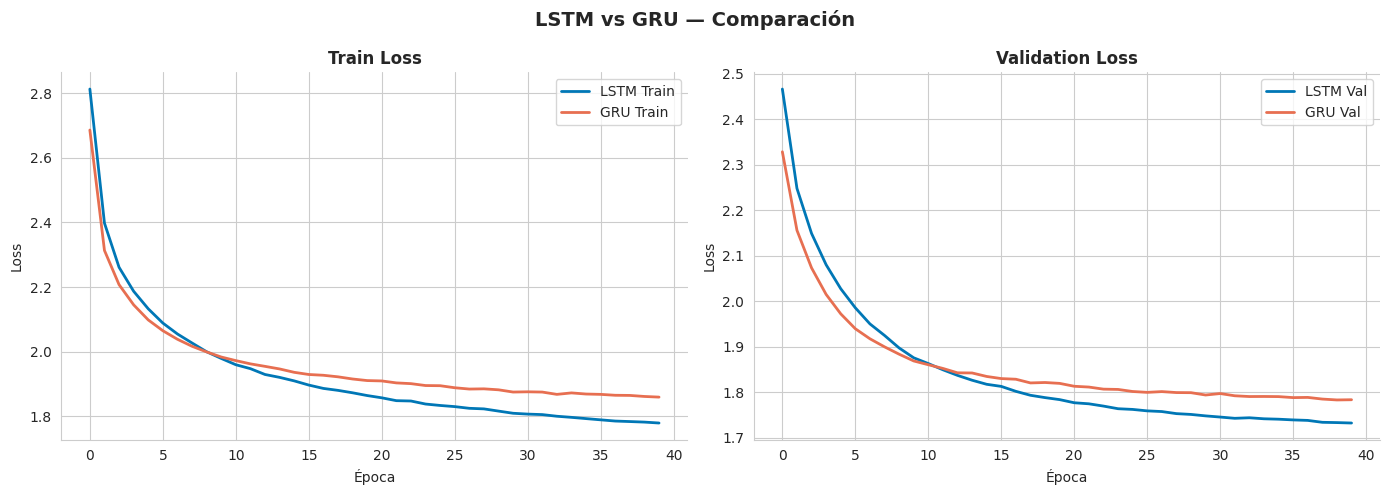


Nombres generados (τ=0.8):
Idioma       | LSTM                           | GRU
Spanish      | ['Hillaniz', 'Salino', 'Virlessa'] | ['Allo', 'Romont', 'Coros']
Japanese     | ['Tagimotri', 'Kiwamatsuki', 'Nisakova'] | ['Kasho', 'Shitamata', 'Shira']
Russian      | ['Nurenkov', 'Togadudg', 'Turainov'] | ['Minaev', 'Dobridnov', 'Grabarov']
English      | ['Drepdon', 'Changleld', 'Flald'] | ['Londreis', 'Masson', 'Felly']
Arabic       | ['Moshada', 'Woudef', 'Mifsud'] | ['Molcos', 'Bazzi', 'Essa']


In [47]:
# Comparación visual LSTM vs GRU

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Train loss
axes[0].plot(train_losses, label='LSTM Train', color='#0077b6', linewidth=2)
axes[0].plot(gru_train_losses, label='GRU Train', color='#e76f51', linewidth=2)
axes[0].set_xlabel('Época')
axes[0].set_ylabel('Loss')
axes[0].set_title('Train Loss', fontweight='bold')
axes[0].legend()
axes[0].spines[['top', 'right']].set_visible(False)

# Val loss
axes[1].plot(val_losses, label='LSTM Val', color='#0077b6', linewidth=2)
axes[1].plot(gru_val_losses, label='GRU Val', color='#e76f51', linewidth=2)
axes[1].set_xlabel('Época')
axes[1].set_ylabel('Loss')
axes[1].set_title('Validation Loss', fontweight='bold')
axes[1].legend()
axes[1].spines[['top', 'right']].set_visible(False)

plt.suptitle('LSTM vs GRU — Comparación', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Generar nombres con GRU para comparación cualitativa
# (reusamos generar_nombre con gru_model — tiene la misma interfaz)
print('\nNombres generados (τ=0.8):')
print(f'{"Idioma":<12s} | {"LSTM":<30s} | {"GRU"}')
print('=' * 80)

# Función para generar con el modelo GRU (misma lógica)
def generar_nombre_gru(modelo, idioma, temperatura=0.8, max_len=20):
    modelo.eval()
    with torch.no_grad():
        input_char = torch.tensor([[SOS_IDX]], dtype=torch.long).to(device)
        lang = torch.tensor([lang_to_idx[idioma]], dtype=torch.long).to(device)
        hidden = None
        nombre_chars = []
        for _ in range(max_len):
            logits, hidden = modelo(input_char, lang, hidden)
            logits = logits[:, -1, :] / temperatura
            probs = torch.softmax(logits, dim=-1)
            next_char_idx = torch.multinomial(probs, 1).item()
            if next_char_idx == EOS_IDX:
                break
            if next_char_idx not in (PAD_IDX, SOS_IDX):
                nombre_chars.append(idx_to_char[next_char_idx])
            input_char = torch.tensor([[next_char_idx]], dtype=torch.long).to(device)
        return ''.join(nombre_chars)

for idioma in ['Spanish', 'Japanese', 'Russian', 'English', 'Arabic']:
    lstm_names = [generar_nombre(model, idioma) for _ in range(3)]
    gru_names = [generar_nombre_gru(gru_model, idioma) for _ in range(3)]
    print(f'{idioma:<12s} | {str(lstm_names):<30s} | {gru_names}')

---

## Instrucciones de Entrega

1. **Formato:** Entrega este notebook (`.ipynb`) con todas las celdas ejecutadas
2. **Código:** Todo el código debe ser ejecutable de principio a fin sin errores
3. **Respuestas:** Todas las preguntas de texto deben estar respondidas
4. **Gráficos:** Todos los gráficos deben estar visibles (no borrar outputs)
5. **Nombre del archivo:** `tarea02_APELLIDO_NOMBRE.ipynb`

---

*Procesamiento de Lenguaje Natural — UCB 2026*